# Optical character recognition (OCR)

In [89]:
# !pip install easyocr

In [90]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imutils
import easyocr

# import os
# os.chdir(r"F:\gam3a\C\Computer Vision\بروجيكت")

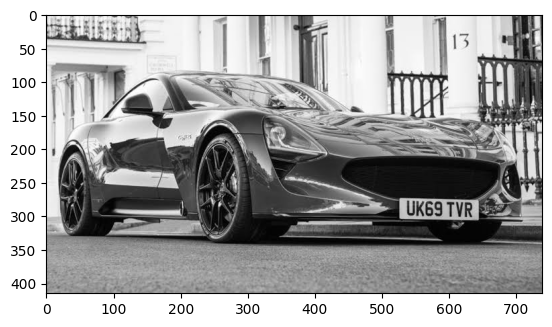

In [91]:
img = cv2.imread("/content/sample_data/image3.jpeg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray,cv2.COLOR_BGR2RGB))


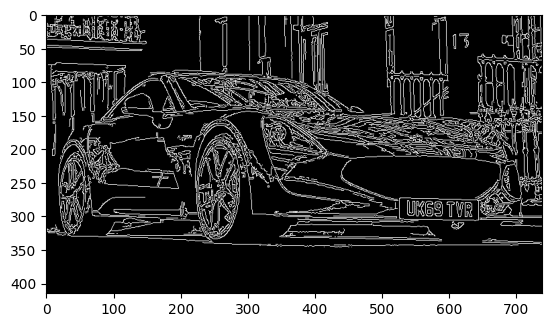

In [92]:
bfilter = cv2.bilateralFilter(gray, 30, 17, 17) #Noise reduction
edged = cv2.Canny(bfilter, 30, 200) #Edge detection
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [93]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contourss = imutils.grab_contours(keypoints)
contours = sorted(contourss, key=cv2.contourArea, reverse=True)[:10]
#print(contours)
len(contours)

10

In [94]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        location = approx
        break
len(location)

4

In [95]:
location


array([[[526, 275]],

       [[642, 275]],

       [[644, 305]],

       [[530, 305]]], dtype=int32)

In [96]:
approx[1][0][0]

642

In [97]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], -1,255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

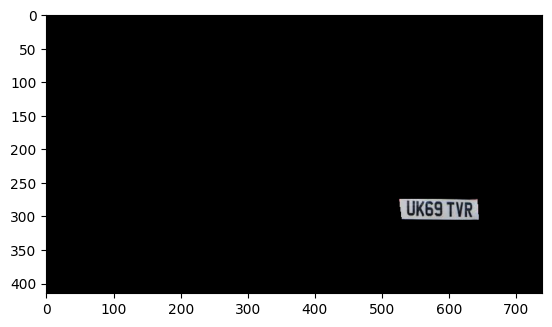

In [98]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))


In [99]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

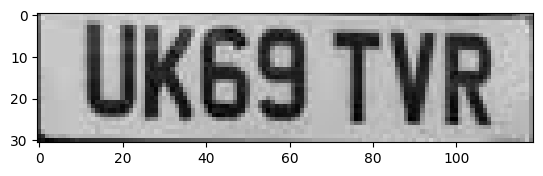

In [100]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))


In [101]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)
result

[([[7, 0], [115, 0], [115, 31], [7, 31]], 'UK69 TVR', 0.6739908443166013)]

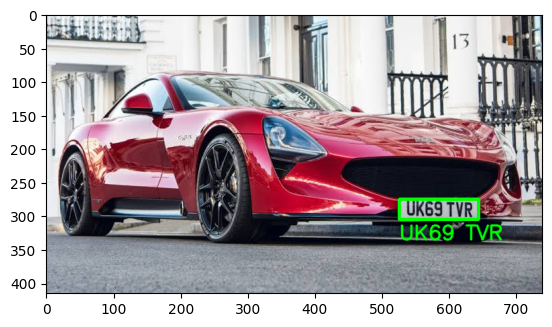

In [102]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))

In [103]:
!pip install pytesseract